# Prompt 5 — MVG Baseline (Ledoit-Wolf + Walk-Forward Tuning)

Multivariate-Gaussian **novelty detector** as the risk-off baseline. Fit on
*normal* (Y=0) weeks only; score = squared Mahalanobis distance; the threshold
epsilon is tuned by **walk-forward CV weighted by the number of positives** per
fold (folds 1-2 dominate; folds 3-5 are statistically noisy and contribute at
the margin).

**Feature set (57 cols = 56 predictors + Y):** `features_stationary_clean` (40,
incl. Y) + `spreads_clean` (16) + **`equity_bond_corr_13w`** (from
`routing_triggers`). Rationale for the 57th feature: the rolling 13-week
equity/bond return correlation **discriminates liquidity-driven crises**
(stocks & bonds fall together, correlation turns positive — e.g. 2008 dash for
cash / 2013 taper) **from inflation-driven regimes** vs the normal negative
stock-bond correlation. It adds a regime axis the price/yield features miss.

**No leakage:** `StandardScaler` is fit per fold on that fold's train only; the
final scaler is fit on the whole 2000-2018 development set for the sealed test.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.splits import walkforward_split
from src.preprocessing import FoldScaler
from src.models import MVGAnomalyDetector, compute_metrics

sns.set_theme(style='whitegrid', context='notebook')
FIG = PROJECT_ROOT / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
MODELS = PROJECT_ROOT / 'outputs' / 'models'; MODELS.mkdir(parents=True, exist_ok=True)
TABLES = PROJECT_ROOT / 'outputs' / 'tables'; TABLES.mkdir(parents=True, exist_ok=True)
ROUTING_PATH = PROJECT_ROOT / 'data' / 'processed' / 'routing_triggers.parquet'
GREEN, RED = '#1a9850', '#d73027'

## 1. Load the 57-column model feature set + walk-forward splits
`equity_bond_corr_13w` starts 2001-01-02 (routing 52w warm-up), so joining it
introduces NaNs in the earliest 2000 weeks; we drop those rows (only ~47 early
training weeks per fold are lost, validation/test windows are unaffected).

In [2]:
wf = walkforward_split(save=False, verbose=False)
ebc = pd.read_parquet(ROUTING_PATH)['equity_bond_corr_13w']

def enrich(df):
    return df.join(ebc, how='left').dropna(subset=['equity_bond_corr_13w'])

folds = [{'fold_id': f['fold_id'], 'train': enrich(f['train']),
          'val': enrich(f['val']), 'crisis_captured': f['crisis_captured']}
         for f in wf['models']['cv_folds']]
dev = enrich(wf['models']['development'])
test = enrich(wf['models']['test_holdout'])

n_features = dev.shape[1] - 1  # minus Y
print(f'Total columns: {dev.shape[1]} (predictive features: {n_features}, + Y)')
print(f'development: {len(dev)} rows | test_holdout: {len(test)} rows')
for f in folds:
    print(f"  fold {f['fold_id']}: train {len(f['train'])} "
          f"(normals {(f['train']['Y']==0).sum()}) | val {len(f['val'])} "
          f"(pos {int(f['val']['Y'].sum())}) | {f['crisis_captured']}")

Total columns: 57 (predictive features: 56, + Y)
development: 939 rows | test_holdout: 121 rows
  fold 1: train 313 (normals 254) | val 153 (pos 53) | GFC 2008
  fold 2: train 470 (normals 358) | val 152 (pos 64) | Euro 2011
  fold 3: train 626 (normals 449) | val 101 (pos 2) | Taper 2013
  fold 4: train 731 (normals 552) | val 100 (pos 10) | China-Oil 2015-16
  fold 5: train 835 (normals 646) | val 100 (pos 6) | Q4 2018 selloff


## 2. Per-fold scaling + MVG walk-forward threshold tuning
For each fold: fit the fold scaler on its train, fit MVG on the scaled train
normals, build a threshold grid from the 80-99th percentiles of the
train-normals Mahalanobis distances, pick the threshold maximizing val F1, and
record all six metrics. Final epsilon = n_pos-weighted **median** of the
per-fold optima.

In [3]:
scaler = FoldScaler(target_col='Y').fit_per_fold(folds)
mvg = MVGAnomalyDetector(shrinkage='ledoit-wolf')
results = mvg.fit_threshold_walkforward(folds, scaler)
print(f'epsilon_final (weighted median): {mvg.threshold_:.2f}\n')
results.round(3)

epsilon_final (weighted median): 81.74



,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,1,313,153,53,81.741,0.596,0.424,1.0,0.826,0.823,0.786
1,2,470,152,64,68.894,0.618,0.448,1.0,0.809,0.800,0.802
2,3,626,101,2,73.880,0.077,0.042,0.5,0.631,0.043,0.156
3,4,731,100,10,141.723,0.294,0.208,0.5,0.682,0.209,0.391
4,5,835,100,6,97.310,0.500,0.500,0.5,0.918,0.350,0.500


## 3. Final fit on development + sealed test-holdout evaluation
Final scaler fit on the entire development set; MVG re-fit on **all**
development normals; epsilon_final (from CV) applied to the test holdout. With
standardized features the squared Mahalanobis ~ chi^2(56), so the per-fold-tuned
epsilon transfers to the development-fit model.

In [4]:
scaler.fit_on_development(dev)
dev_normals = dev[dev['Y'] == 0]
mvg.fit(scaler.transform_holdout(dev_normals))

X_test = scaler.transform_holdout(test)
s_test = mvg.score_samples(X_test)
y_test = test['Y'].to_numpy()
y_pred_test = (s_test >= mvg.threshold_).astype(int)
test_metrics = compute_metrics(y_test, y_pred_test, s_test)
print('Test holdout metrics:', {k: round(v, 3) for k, v in test_metrics.items()})

# Persist final model + scaler
mvg.save(MODELS / 'mvg_final.pkl')
scaler.save(MODELS / 'scaler_final.pkl')
print('Saved mvg_final.pkl + scaler_final.pkl')

Test holdout metrics: {'F1': 0.635, 'Precision': 0.5, 'Recall': 0.87, 'AUC_ROC': 0.883, 'AUC_PR': 0.764, 'F_beta_2': 0.758}
Saved mvg_final.pkl + scaler_final.pkl


## 4. Summary table -> `outputs/tables/mvg_walkforward.csv`

In [5]:
notes = {1: 'Primary', 2: 'Primary', 3: 'Noisy, n_pos=2',
         4: 'Caveat, n_pos=10', 5: 'Noisy, n_pos=6'}
table = results.copy()
table['note'] = table['fold_id'].map(notes)

ws = mvg.weighted_summary()
wrow = {'fold_id': 'weighted_mean', 'n_train': int(results.n_train.sum()),
        'n_val': int(results.n_val.sum()), 'n_pos_val': int(results.n_pos_val.sum()),
        'epsilon_optimal': ws['epsilon_optimal'], 'F1': ws['F1'],
        'Precision': ws['Precision'], 'Recall': ws['Recall'], 'AUC_ROC': ws['AUC_ROC'],
        'AUC_PR': ws['AUC_PR'], 'F_beta_2': ws['F_beta_2'],
        'note': 'n_pos-weighted (median eps)'}
trow = {'fold_id': 'test_holdout', 'n_train': int(len(dev_normals)),
        'n_val': int(len(test)), 'n_pos_val': int(y_test.sum()),
        'epsilon_optimal': mvg.threshold_, **test_metrics, 'note': 'final eval (COVID)'}
cols = ['fold_id', 'n_train', 'n_val', 'n_pos_val', 'epsilon_optimal', 'F1',
        'Precision', 'Recall', 'AUC_ROC', 'AUC_PR', 'F_beta_2', 'note']
table = pd.concat([table, pd.DataFrame([wrow, trow])], ignore_index=True)[cols]
table.to_csv(TABLES / 'mvg_walkforward.csv', index=False)
table.round(3)

,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2,note
0,1,313,153,53,81.741,0.596,0.424,1.000,0.826,0.823,0.786,Primary
1,2,470,152,64,68.894,0.618,0.448,1.000,0.809,0.800,0.802,Primary
2,3,626,101,2,73.880,0.077,0.042,0.500,0.631,0.043,0.156,"Noisy, n_pos=2"
3,4,731,100,10,141.723,0.294,0.208,0.500,0.682,0.209,0.391,"Caveat, n_pos=10"
4,5,835,100,6,97.310,0.500,0.500,0.500,0.918,0.350,0.500,"Noisy, n_pos=6"
5,weighted_mean,2975,606,135,81.741,0.572,0.417,0.933,0.808,0.734,0.742,n_pos-weighted (median eps)
6,test_holdout,744,121,23,81.741,0.635,0.500,0.870,0.883,0.764,0.758,final eval (COVID)


## 5. Figures
### 5.1 Mahalanobis score distribution — train normals vs Fold 1+2 anomalies

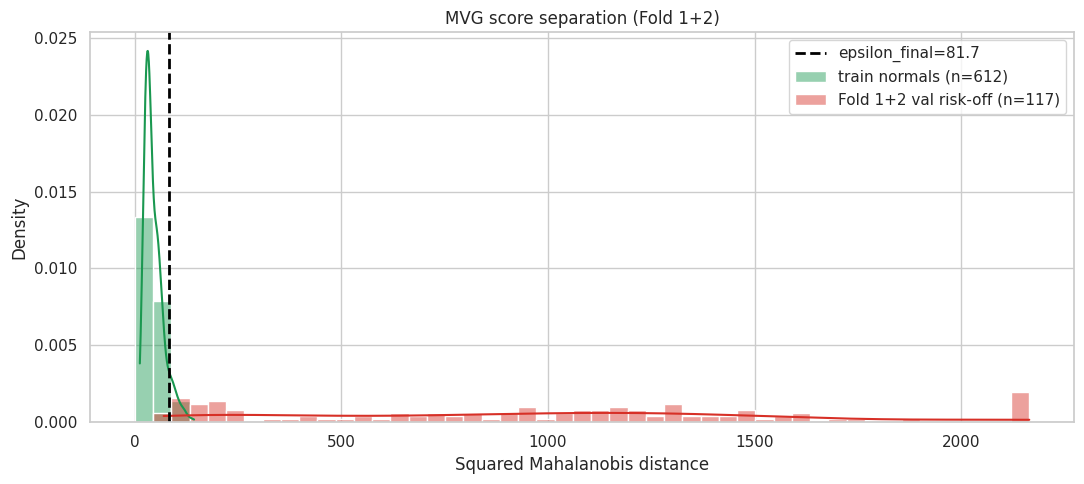

In [6]:
d1 = next(d for d in mvg.fold_details_ if d['fold_id'] == 1)
d2 = next(d for d in mvg.fold_details_ if d['fold_id'] == 2)
green = np.concatenate([d1['scores_train_normals'], d2['scores_train_normals']])
red = np.concatenate([d1['scores_val'][d1['y_val'] == 1], d2['scores_val'][d2['y_val'] == 1]])

fig, ax = plt.subplots(figsize=(11, 5))
clip = np.percentile(np.concatenate([green, red]), 99)
bins = np.linspace(0, clip, 50)
sns.histplot(np.clip(green, 0, clip), bins=bins, stat='density', kde=True, color=GREEN,
             alpha=0.45, label=f'train normals (n={len(green)})', ax=ax)
sns.histplot(np.clip(red, 0, clip), bins=bins, stat='density', kde=True, color=RED,
             alpha=0.45, label=f'Fold 1+2 val risk-off (n={len(red)})', ax=ax)
ax.axvline(mvg.threshold_, color='black', ls='--', lw=2, label=f'epsilon_final={mvg.threshold_:.1f}')
ax.set_xlabel('Squared Mahalanobis distance'); ax.set_title('MVG score separation (Fold 1+2)')
ax.legend(); fig.tight_layout(); fig.savefig(FIG / 'mvg_score_distribution.png', dpi=130)
plt.show()

### 5.2 Test-holdout timeline — Mahalanobis distance, true risk-off shaded, epsilon overlay

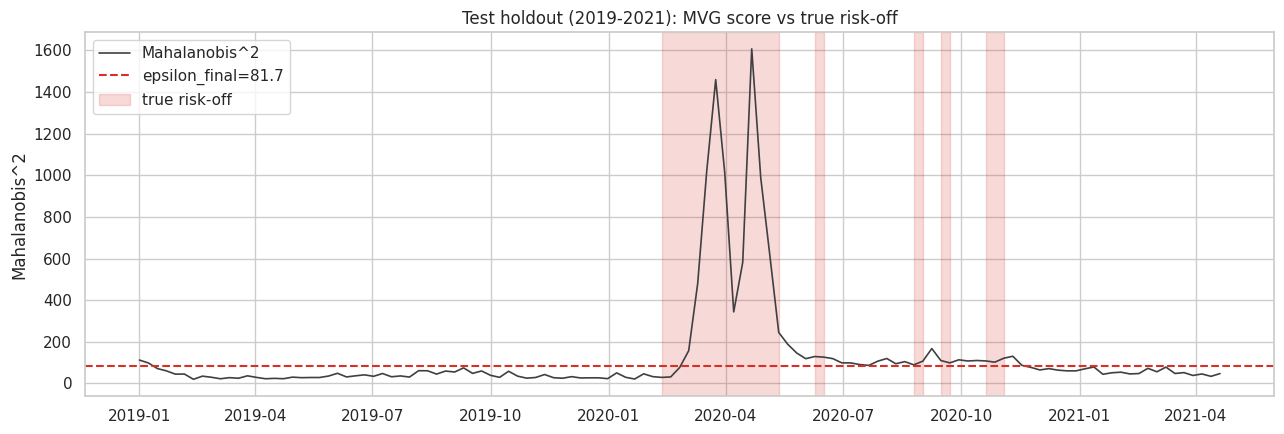

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(test.index, s_test, color='0.25', lw=1.2, label='Mahalanobis^2')
ax.axhline(mvg.threshold_, color=RED, ls='--', lw=1.5, label=f'epsilon_final={mvg.threshold_:.1f}')
y = y_test; idx = test.index; i = 0
first = True
while i < len(y):
    if y[i] == 1:
        j = i
        while j + 1 < len(y) and y[j + 1] == 1:
            j += 1
        ax.axvspan(idx[i], idx[j], color=RED, alpha=0.18,
                   label='true risk-off' if first else None)
        first = False; i = j + 1
    else:
        i += 1
ax.set_title('Test holdout (2019-2021): MVG score vs true risk-off'); ax.set_ylabel('Mahalanobis^2')
ax.legend(loc='upper left'); fig.tight_layout(); fig.savefig(FIG / 'mvg_test_timeline.png', dpi=130)
plt.show()

### 5.3 / 5.4 ROC and Precision-Recall on the test holdout

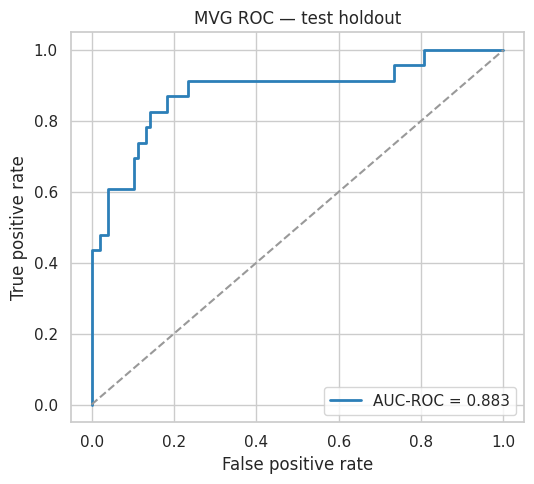

In [8]:
fpr, tpr, _ = roc_curve(y_test, s_test)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color='#2c7fb8', lw=2, label=f"AUC-ROC = {test_metrics['AUC_ROC']:.3f}")
ax.plot([0, 1], [0, 1], '--', color='0.6')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('MVG ROC — test holdout'); ax.legend(loc='lower right')
fig.tight_layout(); fig.savefig(FIG / 'mvg_test_roc.png', dpi=130); plt.show()

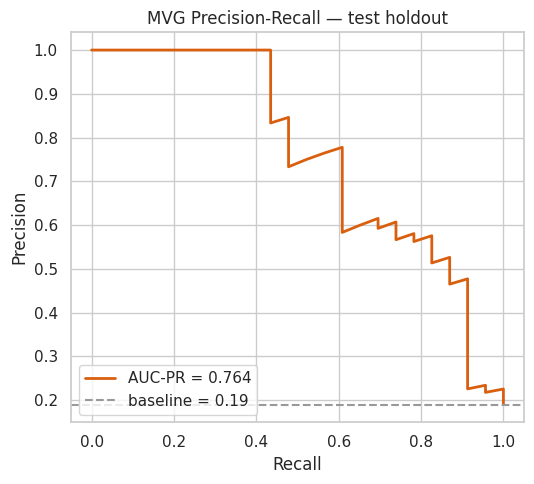

In [9]:
prec, rec, _ = precision_recall_curve(y_test, s_test)
base = y_test.mean()
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(rec, prec, color='#d95f0e', lw=2, label=f"AUC-PR = {test_metrics['AUC_PR']:.3f}")
ax.axhline(base, ls='--', color='0.6', label=f'baseline = {base:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('MVG Precision-Recall — test holdout'); ax.legend(loc='lower left')
fig.tight_layout(); fig.savefig(FIG / 'mvg_test_pr.png', dpi=130); plt.show()

### 5.5 Confusion matrix on the test holdout

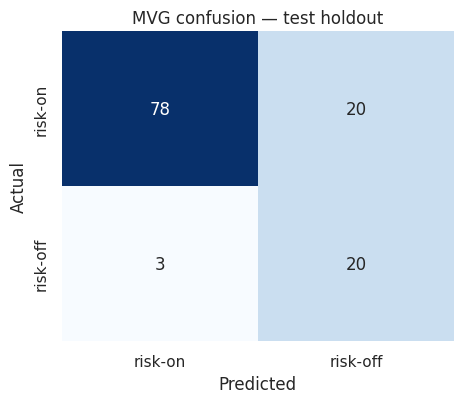

In [10]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['risk-on', 'risk-off'], yticklabels=['risk-on', 'risk-off'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('MVG confusion — test holdout')
fig.tight_layout(); fig.savefig(FIG / 'mvg_test_confusion.png', dpi=130); plt.show()

## 6. Sanity checks (PASS/FAIL)

In [11]:
def check(desc, ok, val):
    print(f"  [{'PASS' if ok else 'FAIL'}] {desc} (got {val:.3f})")

print('Walk-forward (n_pos-weighted) + test-holdout sanity:')
check('F1 weighted folds > 0.40', ws['F1'] > 0.40, ws['F1'])
check('AUC-PR weighted folds > 0.35', ws['AUC_PR'] > 0.35, ws['AUC_PR'])
check('F1 test holdout > 0.50', test_metrics['F1'] > 0.50, test_metrics['F1'])
check('AUC-ROC test holdout > 0.80', test_metrics['AUC_ROC'] > 0.80, test_metrics['AUC_ROC'])
check('AUC-PR test holdout > 0.55', test_metrics['AUC_PR'] > 0.55, test_metrics['AUC_PR'])

f3 = results[results.fold_id == 3].iloc[0]
if f3['F1'] == 0 and f3['n_pos_val'] <= 2:
    print(f"  [WARN] Fold 3 F1=0 with only n_pos={int(f3['n_pos_val'])} "
          'positives — statistically degenerate, not blocking (down-weighted in CV).')

Walk-forward (n_pos-weighted) + test-holdout sanity:
  [PASS] F1 weighted folds > 0.40 (got 0.572)
  [PASS] AUC-PR weighted folds > 0.35 (got 0.734)
  [PASS] F1 test holdout > 0.50 (got 0.635)
  [PASS] AUC-ROC test holdout > 0.80 (got 0.883)
  [PASS] AUC-PR test holdout > 0.55 (got 0.764)


## 7. Takeaways
- Ledoit-Wolf shrinkage was required: with 56 features and ~250 normals in
  Fold 1 the empirical covariance is near-singular.
- Folds 1-2 (GFC, euro crisis) carry the CV signal; folds 3-5 are thin and
  down-weighted by `n_pos`. The weighted-median epsilon avoids overfitting to
  the noisy low-prevalence folds.
- COVID in the test holdout is the 'easy' regime (VIX exploded), so the MVG
  baseline already separates it well — later models (SVM/AE/IF) and the
  ensemble must beat this bar.